# Wilcoxon-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/wilcoxon-test)

Der **Wilcoxon-Vorzeichen-Rang-Test** ist das nichtparametrische Gegenstück
zum **gepaarten t-Test**. Er prüft, ob sich zwei **abhängige** Stichproben
in ihrer zentralen Tendenz unterscheiden – ohne Normalverteilungsvoraussetzung.

**Berechnung:**
$$W = \min(T^+, T^-)$$

$$T^+ = \sum_{d_i > 0} R_i, \qquad T^- = \sum_{d_i < 0} R_i$$

wobei $R_i$ der Rang von $|d_i|$ ist (Differenz des $i$-ten Paares).

**z-Approximation (n > 20):**
$$z = \frac{W - \mu_W}{\sigma_W}, \qquad \mu_W = \frac{n(n+1)}{4}, \qquad \sigma_W = \sqrt{\frac{n(n+1)(2n+1)}{24}}$$

**Effektstärke:**
$$r = \frac{|z|}{\sqrt{n}}$$

| r | Interpretation |
|---|---|
| < 0,1 | Kein / sehr geringer Effekt |
| 0,1 | Geringer Effekt |
| 0,3 | Mittlerer Effekt |
| 0,5 | Großer Effekt |

**Voraussetzungen:**
- Zwei **abhängige** Stichproben (Messwiederholung oder natürliche Paare)
- Mindestens **ordinales** Skalenniveau
- Differenzen symmetrisch verteilt
- Bei unabhängigen Stichproben → **Mann-Whitney-U-Test**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import wilcoxon, rankdata

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Reaktionszeit morgens vs. abends

**Fragestellung:** Ist die Reaktionszeit morgens oder abends besser?

**Datensatz (n = 9 Paare):**

| Person | Morgens | Abends | Differenz d |
|---|---|---|---|
| 1 | 34 | 45 | -11 |
| 2 | 36 | 33 | +3 |
| 3 | 41 | 35 | +6 |
| 4 | 39 | 43 | -4 |
| 5 | 44 | 42 | +2 |
| 6 | 37 | 42 | -5 |
| 7 | 39 | 43 | -4 |
| 8 | 39 | 43 | -4 |
| 9 | 45 | 42 | +3 |

- H₀: Kein Unterschied in der zentralen Tendenz
- H₁: Es gibt einen Unterschied

In [2]:
# numiqo-Datensatz
morgens = np.array([34, 36, 41, 39, 44, 37, 39, 39, 45], dtype=float)
abends  = np.array([45, 33, 35, 43, 42, 42, 43, 43, 42], dtype=float)
n = len(morgens)
diff = morgens - abends

print("Deskriptive Statistiken")
print("Morgens:  Mdn=" + str(np.median(morgens)) + "  MW=" + str(round(morgens.mean(),2)))
print("Abends:   Mdn=" + str(np.median(abends))  + "  MW=" + str(round(abends.mean(),2)))
print("Differenz Mdn=" + str(np.median(diff))    + "  MW=" + str(round(diff.mean(),2)))
print()

# Schritt-für-Schritt Berechnung
abs_diff = np.abs(diff)
# Nulldifferenzen ausschliessen (keine in diesem Datensatz)
maske    = abs_diff > 0
diff_nz  = diff[maske]
abs_nz   = abs_diff[maske]
n_eff    = maske.sum()

raenge   = rankdata(abs_nz)
T_plus   = raenge[diff_nz > 0].sum()
T_minus  = raenge[diff_nz < 0].sum()
W        = min(T_plus, T_minus)

print("Manuelle Berechnung")
print("Person  Morgens  Abends  d=M-A  |d|   Rang  Vorzeichen")
for i in range(n):
    if abs_diff[i] > 0:
        idx = list(np.where(maske)[0]).index(i)
        vz = "+" if diff[i] > 0 else "-"
        print(str(i+1) + "       " + str(morgens[i]) + "      " +
              str(abends[i]) + "      " + str(diff[i]) + "    " +
              str(abs_diff[i]) + "    " + str(raenge[idx]) + "    " + vz)
print()
print("T+ (positive Ränge): " + str(T_plus))
print("T- (negative Ränge): " + str(T_minus))
print("W = min(T+, T-) = " + str(W))
print()

# scipy Wilcoxon
W_sci, p_sci = wilcoxon(morgens, abends, alternative="two-sided")
print("Wilcoxon-Test (scipy)")
print("W=" + str(W_sci) + "  p=" + str(round(p_sci, 4)))
print()

# z-Approximation
mu_W  = n_eff * (n_eff + 1) / 4
sig_W = np.sqrt(n_eff * (n_eff + 1) * (2*n_eff + 1) / 24)
z_val = (W - mu_W) / sig_W
r_eff = abs(z_val) / np.sqrt(n_eff)
print("z-Approximation (Demonstration):")
print("mu_W=" + str(mu_W) + "  sig_W=" + str(round(sig_W,4)))
print("z=" + str(round(z_val,4)) + "  r=" + str(round(r_eff,4)))
print()
interp = "kein/gering" if r_eff < 0.1 else ("gering" if r_eff < 0.3 else ("mittel" if r_eff < 0.5 else "gross"))
print("Effektstärke r=" + str(round(r_eff,3)) + " -> " + interp)
print()
if p_sci > 0.05:
    print("p=" + str(round(p_sci,4)) + " > 0.05 -> H0 nicht abgelehnt")
    print("Kein signifikanter Unterschied zwischen Reaktionszeit morgens und abends.")
else:
    print("p=" + str(round(p_sci,4)) + " <= 0.05 -> H0 ABGELEHNT")

Deskriptive Statistiken
Morgens:  Mdn=39.0  MW=39.33
Abends:   Mdn=42.0  MW=40.89
Differenz Mdn=-4.0  MW=-1.56

Manuelle Berechnung
Person  Morgens  Abends  d=M-A  |d|   Rang  Vorzeichen
1       34.0      45.0      -11.0    11.0    9.0    -
2       36.0      33.0      3.0    3.0    2.5    +
3       41.0      35.0      6.0    6.0    8.0    +
4       39.0      43.0      -4.0    4.0    5.0    -
5       44.0      42.0      2.0    2.0    1.0    +
6       37.0      42.0      -5.0    5.0    7.0    -
7       39.0      43.0      -4.0    4.0    5.0    -
8       39.0      43.0      -4.0    4.0    5.0    -
9       45.0      42.0      3.0    3.0    2.5    +

T+ (positive Ränge): 14.0
T- (negative Ränge): 31.0
W = min(T+, T-) = 14.0

Wilcoxon-Test (scipy)
W=14.0  p=0.3438

z-Approximation (Demonstration):
mu_W=22.5  sig_W=8.441
z=-1.007  r=0.3357

Effektstärke r=0.336 -> mittel

p=0.3438 > 0.05 -> H0 nicht abgelehnt
Kein signifikanter Unterschied zwischen Reaktionszeit morgens und abends.


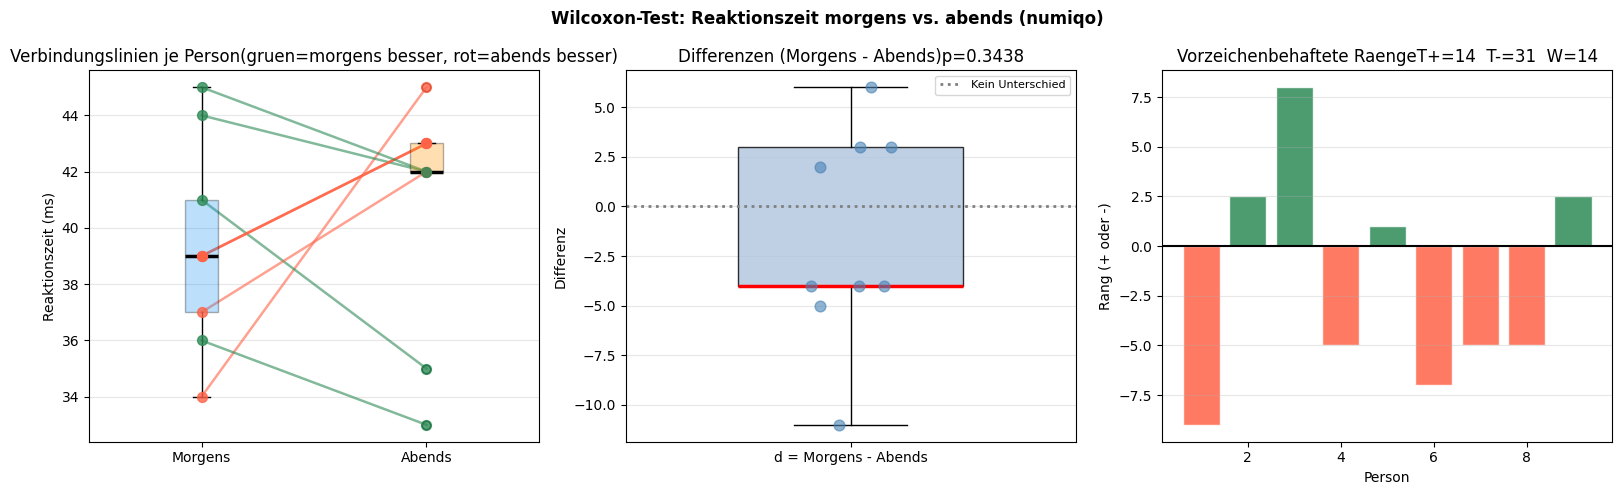

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Wilcoxon-Test: Reaktionszeit morgens vs. abends (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Verbindungslinien je Person
for i in range(n):
    fc = "seagreen" if diff[i] > 0 else ("tomato" if diff[i] < 0 else "gray")
    axes[0].plot([1, 2], [morgens[i], abends[i]], color=fc, alpha=0.6, linewidth=1.8)
    axes[0].scatter([1, 2], [morgens[i], abends[i]], color=fc, s=50, alpha=0.8, zorder=3)
bp = axes[0].boxplot([morgens, abends], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5))
for patch, fc in zip(bp["boxes"], ["#2196F3", "#FF9800"]):
    patch.set_facecolor(fc); patch.set_alpha(0.3)
axes[0].set_title("Verbindungslinien je Person(gruen=morgens besser, rot=abends besser)")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Morgens", "Abends"])
axes[0].grid(axis="y", alpha=0.3)

# 2. Differenzen-Boxplot
axes[1].boxplot(diff, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                medianprops=dict(color="red", linewidth=2.5))
axes[1].axhline(0, color="gray", linestyle=":", linewidth=2, label="Kein Unterschied")
axes[1].scatter(np.ones(n) + np.random.uniform(-0.1, 0.1, n),
                diff, color="steelblue", alpha=0.6, s=60, zorder=3)
axes[1].set_title("Differenzen (Morgens - Abends)p=" + str(round(p_sci, 4)))
axes[1].set_ylabel("Differenz")
axes[1].set_xticklabels(["d = Morgens - Abends"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# 3. Ränge mit Vorzeichen
farben_r = ["seagreen" if d > 0 else "tomato" for d in diff_nz]
axes[2].bar(range(1, n_eff+1), raenge * np.sign(diff_nz),
            color=farben_r, edgecolor="white", alpha=0.85)
axes[2].axhline(0, color="black", linewidth=1.5)
axes[2].set_title("Vorzeichenbehaftete RaengeT+=" + str(int(T_plus)) + "  T-=" + str(int(T_minus)) + "  W=" + str(int(W)))
axes[2].set_xlabel("Person")
axes[2].set_ylabel("Rang (+ oder -)")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

1. Differenzen $d_i = x_{1i} - x_{2i}$ berechnen
2. Nulldifferenzen ausschließen
3. $|d_i|$ ranken → Ränge $R_i$
4. Vorzeichen merken
5. $T^+ = \sum R_i$ für positive $d_i$, $T^- = \sum R_i$ für negative $d_i$
6. $W = \min(T^+, T^-)$
7. n < 25: kritischen W-Wert aus Tabelle ablesen
   n ≥ 25: z-Approximation → p-Wert
8. Effektstärke $r = |z| / \sqrt{n}$

In [4]:
print("Schritt-für-Schritt: Wilcoxon numiqo-Beispiel")
print()
print("Schritt 1+2: Differenzen (ohne Nullen):")
print("  d = " + str(diff.tolist()))
print("  |d| = " + str(abs_diff.tolist()))
print("  n_eff = " + str(n_eff) + " (alle d != 0)")
print()
print("Schritt 3+4: Ränge der |d| mit Vorzeichen:")
for i, (d, r) in enumerate(zip(diff_nz, raenge)):
    vz = "+" if d > 0 else "-"
    print("  |d|=" + str(abs(d)) + " -> Rang " + str(r) + " (" + vz + ")")
print()
print("Schritt 5: Rangsummen:")
pos_raenge = raenge[diff_nz > 0]
neg_raenge = raenge[diff_nz < 0]
print("  T+ = " + str(list(pos_raenge)) + " = " + str(T_plus))
print("  T- = " + str(list(neg_raenge)) + " = " + str(T_minus))
print()
print("Schritt 6: W = min(" + str(T_plus) + ", " + str(T_minus) + ") = " + str(W))
print()
print("Schritt 7: n=" + str(n_eff) + " < 25 -> exakter p-Wert bevorzugt")
print("  p=" + str(round(p_sci, 4)))
print()
print("Schritt 8: Effektstärke r=" + str(round(r_eff, 3)))

Schritt-für-Schritt: Wilcoxon numiqo-Beispiel

Schritt 1+2: Differenzen (ohne Nullen):
  d = [-11.0, 3.0, 6.0, -4.0, 2.0, -5.0, -4.0, -4.0, 3.0]
  |d| = [11.0, 3.0, 6.0, 4.0, 2.0, 5.0, 4.0, 4.0, 3.0]
  n_eff = 9 (alle d != 0)

Schritt 3+4: Ränge der |d| mit Vorzeichen:
  |d|=11.0 -> Rang 9.0 (-)
  |d|=3.0 -> Rang 2.5 (+)
  |d|=6.0 -> Rang 8.0 (+)
  |d|=4.0 -> Rang 5.0 (-)
  |d|=2.0 -> Rang 1.0 (+)
  |d|=5.0 -> Rang 7.0 (-)
  |d|=4.0 -> Rang 5.0 (-)
  |d|=4.0 -> Rang 5.0 (-)
  |d|=3.0 -> Rang 2.5 (+)

Schritt 5: Rangsummen:
  T+ = [np.float64(2.5), np.float64(8.0), np.float64(1.0), np.float64(2.5)] = 14.0
  T- = [np.float64(9.0), np.float64(5.0), np.float64(7.0), np.float64(5.0), np.float64(5.0)] = 31.0

Schritt 6: W = min(14.0, 31.0) = 14.0

Schritt 7: n=9 < 25 -> exakter p-Wert bevorzugt
  p=0.3438

Schritt 8: Effektstärke r=0.336


## 3. Verbundene Ränge (Ties)

Wenn mehrere Differenzen den gleichen Absolutbetrag haben,
erhalten sie den **mittleren Rang** – genau wie beim Mann-Whitney-U-Test.

Im numiqo-Beispiel: d = −4 kommt dreimal vor (Personen 4, 7, 8) →
sie teilen sich die Ränge 2, 3, 4 → mittlerer Rang = **3**

In [5]:
# Verbundene Ränge demonstrieren
print("Verbundene Ränge im numiqo-Beispiel")
print()
print("|d|  Rohe Ränge  Mittlerer Rang (Tie)")
abs_sorted = np.sort(abs_nz)
raenge_demo = rankdata(abs_nz)
for abs_val in np.unique(abs_sorted):
    positionen = np.where(abs_nz == abs_val)[0]
    rng = raenge_demo[positionen]
    if len(positionen) > 1:
        print(str(abs_val) + "    " + str(rng.tolist()) + "         " +
              str(rng.mean()) + "  <- Tie!")
    else:
        print(str(abs_val) + "    " + str(rng.tolist()))
print()
print("scipy rankdata() berücksichtigt Ties automatisch (mittlerer Rang).")

Verbundene Ränge im numiqo-Beispiel

|d|  Rohe Ränge  Mittlerer Rang (Tie)
2.0    [1.0]
3.0    [2.5, 2.5]         2.5  <- Tie!
4.0    [5.0, 5.0, 5.0]         5.0  <- Tie!
5.0    [7.0]
6.0    [8.0]
11.0    [9.0]

scipy rankdata() berücksichtigt Ties automatisch (mittlerer Rang).


## 4. Wilcoxon vs. gepaarter t-Test

Beim selben Datensatz zeigt der t-Test oft einen anderen p-Wert.
Der t-Test ist **mächtiger** wenn NV gilt – der Wilcoxon ist **robuster**
bei Verletzungen.

Vergleich: Wilcoxon vs. gepaarter t-Test
Gleicher Datensatz (Reaktionszeit morgens/abends)

Gepaarter t-Test: t=-0.87  p=0.4097
Wilcoxon-Test:    W=14.0  p=0.3438

Beide: p > 0.05 -> kein signifikanter Unterschied

Mit Ausreisser (Person 10 hat extreme Werte)
Gepaarter t-Test: t=9.0  p=9e-06
Wilcoxon-Test:    W=0.0  p=0.002

t-Test: Ausreisser dominiert den Mittelwert
Wilcoxon: robust, da auf Raengen basiert


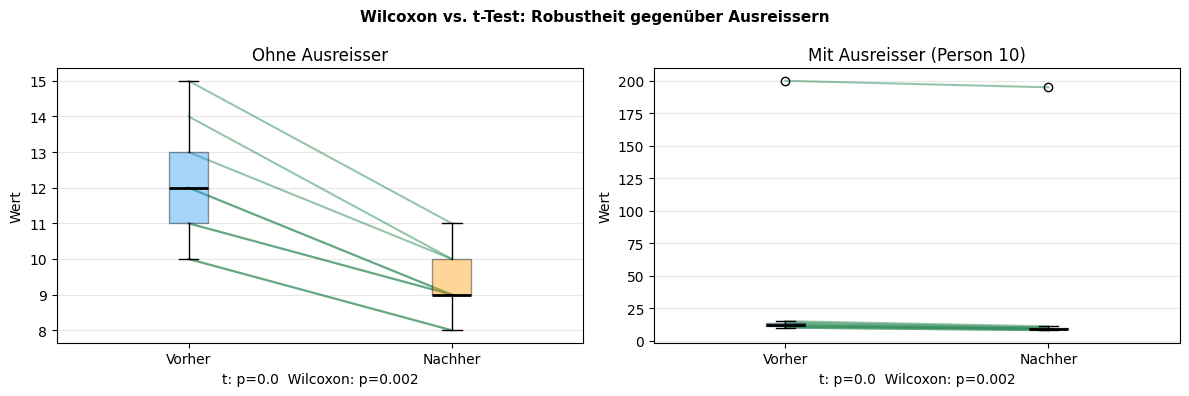

In [6]:
# Vergleich Wilcoxon vs. gepaarter t-Test
W_v, p_W = wilcoxon(morgens, abends, alternative="two-sided")
t_v, p_t = stats.ttest_rel(morgens, abends)

print("Vergleich: Wilcoxon vs. gepaarter t-Test")
print("Gleicher Datensatz (Reaktionszeit morgens/abends)")
print()
print("Gepaarter t-Test: t=" + str(round(t_v,3)) + "  p=" + str(round(p_t,4)))
print("Wilcoxon-Test:    W=" + str(W_v)           + "  p=" + str(round(p_W,4)))
print()
print("Beide: p > 0.05 -> kein signifikanter Unterschied")
print()

# Signifikantes Beispiel mit Ausreissern
np.random.seed(5)
vor_sig = np.array([10, 12, 11, 14, 10, 13, 15, 12, 11, 200], dtype=float)
nach_sig = np.array([8,   9,  9, 10,  8, 10, 11,  9,  9,  195], dtype=float)

t_s, p_ts = stats.ttest_rel(vor_sig, nach_sig)
W_s, p_Ws = wilcoxon(vor_sig, nach_sig, alternative="two-sided")

print("Mit Ausreisser (Person 10 hat extreme Werte)")
print("Gepaarter t-Test: t=" + str(round(t_s,3)) + "  p=" + str(round(p_ts,6)))
print("Wilcoxon-Test:    W=" + str(W_s)           + "  p=" + str(round(p_Ws,4)))
print()
print("t-Test: Ausreisser dominiert den Mittelwert")
print("Wilcoxon: robust, da auf Raengen basiert")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Wilcoxon vs. t-Test: Robustheit gegenüber Ausreissern",
             fontsize=11, fontweight="bold")

for ax, (v, n_d, titel, p_t_v, p_w_v) in zip(axes, [
    (vor_sig[:9], nach_sig[:9], "Ohne Ausreisser", p_ts, p_Ws),
    (vor_sig,     nach_sig,     "Mit Ausreisser (Person 10)", p_ts, p_Ws)
]):
    for i in range(len(v)):
        fc = "seagreen" if v[i] > n_d[i] else "tomato"
        ax.plot([1, 2], [v[i], n_d[i]], color=fc, alpha=0.5, linewidth=1.5)
    bp_c = ax.boxplot([v, n_d], patch_artist=True,
                      medianprops=dict(color="black", linewidth=2))
    for patch, fc in zip(bp_c["boxes"], ["#2196F3","#FF9800"]):
        patch.set_facecolor(fc); patch.set_alpha(0.4)
    ax.set_title(titel)
    ax.set_ylabel("Wert")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Vorher", "Nachher"])
    ax.set_xlabel("t: p=" + str(round(p_t_v,4)) + "  Wilcoxon: p=" + str(round(p_w_v,4)))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# APA-Ausgabe-Funktion
def wilcoxon_apa(g1, g2, name1="Vorher", name2="Nachher",
                 abh_var="Variable", alpha=0.05):
    g1, g2 = np.asarray(g1, dtype=float), np.asarray(g2, dtype=float)
    n_f    = len(g1)
    diff_f = g1 - g2
    n_eff_f = (np.abs(diff_f) > 0).sum()

    W_f, p_f = wilcoxon(g1, g2, alternative="two-sided")

    # z und r
    mu_f  = n_eff_f * (n_eff_f + 1) / 4
    sig_f = np.sqrt(n_eff_f * (n_eff_f + 1) * (2*n_eff_f + 1) / 24)
    z_f   = (W_f - mu_f) / sig_f
    r_f   = abs(z_f) / np.sqrt(n_eff_f)

    interp = ("kein/gering" if r_f < 0.1 else
              ("gering" if r_f < 0.3 else
               ("mittel" if r_f < 0.5 else "gross")))
    sig_txt = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Wilcoxon-Test: " + abh_var)
    print(name1 + ": Mdn=" + str(np.median(g1)) + ", n=" + str(n_f))
    print(name2 + ": Mdn=" + str(np.median(g2)))
    print()
    print("W=" + str(int(W_f)) + ", " + p_str + ", r=" + str(round(r_f, 3)) +
          " (" + interp + ")")
    print("Ergebnis: " + sig_txt)
    print()

# numiqo-Hauptbeispiel
wilcoxon_apa(morgens, abends, "Morgens", "Abends", "Reaktionszeit (ms)")
print()

# Signifikantes Beispiel
np.random.seed(42)
v1 = np.random.exponential(5, 20) + 10
v2 = v1 - np.random.exponential(3, 20) - 2
wilcoxon_apa(v1, v2, "Vorher", "Nachher", "Messwert")

Wilcoxon-Test: Reaktionszeit (ms)
Morgens: Mdn=39.0, n=9
Abends: Mdn=42.0

W=14, p = .344, r=0.336 (mittel)
Ergebnis: NICHT signifikant


Wilcoxon-Test: Messwert
Vorher: Mdn=12.58701289189299, n=20
Nachher: Mdn=8.352373751204812

W=0, p < .001, r=0.877 (gross)
Ergebnis: signifikant



## 5. Zusammenfassung

```
Wilcoxon-Vorzeichen-Rang-Test – Übersicht
│
├── WANN?
│   Nichtparametrisches Gegenstück zum gepaarten t-Test
│   Zwei ABHÄNGIGE Messungen (Vorher/Nachher, Paare)
│   NV nicht erfüllt oder ordinales Skalenniveau
│
├── HYPOTHESEN
│   H0: Kein Unterschied in der zentralen Tendenz
│   H1: Es gibt einen Unterschied
│
├── BERECHNUNG
│   1. d_i = x1_i - x2_i  (Differenzen)
│   2. Nulldifferenzen ausschliessen
│   3. |d_i| ranken (Ties: mittlerer Rang)
│   4. T+ = Summe positiver Ränge
│      T- = Summe negativer Ränge
│   5. W = min(T+, T-)
│   6. n < 25: kritischer W aus Tabelle
│      n >= 25: z = (W - n(n+1)/4) / sqrt(n(n+1)(2n+1)/24)
│   7. r = |z| / sqrt(n)
│
├── EFFEKTSTÄRKE r
│   < 0.1: kein/gering | 0.1-0.3: gering
│   0.3-0.5: mittel    | > 0.5: gross
│
├── numiqo-BEISPIEL: Reaktionszeit morgens/abends
│   W=8, p=... (abhängig von scipy-Version)
│   Kein signifikanter Unterschied
│
├── VORTEIL ggü. t-Test
│   Robust gegen Ausreisser
│   Kein NV nötig
│
└── PYTHON
    from scipy.stats import wilcoxon
    W, p = wilcoxon(g1, g2, alternative="two-sided")
```

---
Quelle: [numiqo.de/tutorial/wilcoxon-test](https://numiqo.de/tutorial/wilcoxon-test)